In [ ]:
# basic notebook for plotting logos from annotated seqlets for highlighting specific examples #

In [1]:
# import packages
import pandas as pd
import numpy as np
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import torch
import os
import pickle
# tangermeme packages
from tangermeme.seqlet import recursive_seqlets
from tangermeme.plot import plot_logo
from tangermeme.annotate import annotate_seqlets
from tangermeme.io import read_meme
import logomaker

In [2]:
# dictionary structure for passing to plotting function to:
# filter the summary dataframe for:
# lead variant highlight
# other emVar highlights (with allele frequencies)
# dict(
# cell_type : 'k562',
# enhancer_id : 'ENH...,
# phenotype : 'blah')

In [3]:
def plot_specific_enhancers_v2(enhancer_id,
                               enhStart,
                               chrom,
                               collapsedSeqletBED,
                               cosmicID,
                               cosmicPreds,
                               cell,
                               output_dir='plot_outputs'):
    """
    Updated plotting function that:
    - Colors emVars by exceeds_lead_skew (deepskyblue=exceeds, darkorange=does not)
    - Saves a companion TSV with variant details + population-level AFs
    - Saves the plot as a PDF
    """
    os.makedirs(output_dir, exist_ok=True)
    # filter the cosmic data
    cosmicVarData = cosmicPreds[(cosmicPreds['id'] == cosmicID)]

    # load the tensors
    plotLogo_tensors = torch.load(f'/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/processed_data/seqlets_calling/seqlets_by_chrom/{chrom}_plotLogo_tensors.pt')

    # get the seqlets for the BED file
    enhBED = collapsedSeqletBED[collapsedSeqletBED['enhancer_id'] == enhancer_id]

    # pull the tensors for the enhancer for that cell type
    tensors2plot = plotLogo_tensors[cell][enhancer_id]

    # get the max/min attributions for highlighting seqlets
    minAttrib = tensors2plot.min().min() * 1.05
    maxAttrib = tensors2plot.max().max() * 1.05

    # build the DF for plotting with logomaker
    dfFromTensor = pd.DataFrame(tensors2plot.numpy()).T.copy()
    renamedDF = dfFromTensor.rename(columns={0: 'A', 1: 'C', 2: 'G', 3: 'T'})

    # remove zero-padded positions at ends
    renamedDF = renamedDF.loc[renamedDF.sum(axis=1) != 0]

    # adjust enhStart to account for left padding, then reset index to start at 0
    enhStart = enhStart + renamedDF.index[0]
    renamedDF = renamedDF.reset_index(drop=True)
    seq_length = len(renamedDF)

    # set plot parameters
    matplotlib.rcParams['pdf.fonttype'] = 42
    matplotlib.rcParams['ps.fonttype'] = 42
    matplotlib.rcParams['figure.dpi'] = 300

    # generate base plot with extra space for annotations
    fig, ax = plt.subplots(figsize=[20, 2.5])
    logoCheck = logomaker.Logo(renamedDF, ax=ax)

    # set y-limits based on data only
    logoCheck.ax.set_ylim(minAttrib, maxAttrib)

    # track annotation positions to avoid collisions
    top_annotations = []
    bottom_annotations = []
    min_spacing = 3

    def get_annotation_level(x_center, text_half_width, existing_annotations):
        """Find the lowest level where this annotation won't overlap with others."""
        level = 0
        while True:
            conflict = False
            for other_center, other_half_width, other_level in existing_annotations:
                if other_level == level:
                    distance = abs(x_center - other_center)
                    min_dist = text_half_width + other_half_width + min_spacing
                    if distance < min_dist:
                        conflict = True
                        break
            if not conflict:
                return level
            level += 1

    # highlight seqlets and collect annotation info
    for idx, row in enhBED.iterrows():
        start, stop, actClass, tf = row[['start', 'end', 'activity_class', 'tf_family']].tolist()
        start = int(start - enhStart)
        stop = int(stop - enhStart - 1)
        x_center = (stop + start) / 2
        x_center_norm = x_center / seq_length
        tf_label = tf.split('_')[0]
        text_half_width = len(tf_label) * 2.5

        if actClass == 'Activator':
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', floor=0)
            level = get_annotation_level(x_center, text_half_width, top_annotations)
            top_annotations.append((x_center, text_half_width, level))
            y_offset = 1.05 + level * 0.05
            ax.annotate(tf_label,
                        xy=(x_center_norm, 1.0), xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset), textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='bottom', annotation_clip=False)
        else:
            logoCheck.highlight_position_range(pmin=start, pmax=stop, alpha=0.5, color='gainsboro', edgecolor='k', ceiling=0)
            level = get_annotation_level(x_center, text_half_width, bottom_annotations)
            bottom_annotations.append((x_center, text_half_width, level))
            y_offset = -0.01 - level * 0.12
            ax.annotate(tf_label,
                        xy=(x_center_norm, 0.0), xycoords='axes fraction',
                        xytext=(x_center_norm, y_offset), textcoords='axes fraction',
                        fontsize=8, fontstyle='italic',
                        ha='center', va='top', annotation_clip=False)

    # cosmic variant (red)
    # get position
    cosmicPos = cosmicVarData['pos'].tolist()[0]
    cosmicPos = int(cosmicPos - enhStart - 1)
    logoCheck.highlight_position(p=cosmicPos, color='red', alpha=0.5, floor=0)
    logoCheck.style_spines(visible=False)
    # set x-axis ticks to genomic positions
    first_minor_genomic = ((enhStart // 10) + 1) * 10
    major_tick_positions = []
    major_tick_labels = []
    minor_tick_positions = []

    for genomic_pos in range(first_minor_genomic, enhStart + seq_length, 10):
        plot_pos = genomic_pos - enhStart - 1
        if 0 <= plot_pos < seq_length:
            if genomic_pos % 50 == 0:
                major_tick_positions.append(plot_pos)
                major_tick_labels.append(str(genomic_pos))
            else:
                minor_tick_positions.append(plot_pos)

    ax.set_xticks(major_tick_positions)
    ax.set_xticklabels(major_tick_labels, rotation=45, ha='right', rotation_mode='anchor')
    ax.tick_params(axis='x', which='major', length=5, pad=5)
    ax.set_xticks(minor_tick_positions, minor=True)
    ax.tick_params(axis='x', which='minor', length=2.5)

    plt.title(f'{enhancer_id} | {cell}', loc='left')
    plt.subplots_adjust(top=0.75, bottom=0.25)

    # save plot as PDF
    pdf_path = os.path.join(output_dir, f'{enhancer_id}_{cell}_{cosmicID}_logo.pdf')
    #plt.savefig(pdf_path, bbox_inches='tight', dpi=300)
    print(f'Saved plot: {pdf_path}')

In [4]:
# open dELS seqlet bed files
# k562
k_dELS_seqlets = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/repTF_k562_dELS_seqlets_01_vierstra_clusteded.bed', sep = '\t', low_memory=False)
# hepg2
h_dELS_seqlets = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/repTF_hepg2_dELS_seqlets_01_vierstra_clusteded.bed', sep = '\t', low_memory=False)
# sknsh
s_dELS_seqlets = pd.read_csv('/projects/tewhey-lab/buttsj/Variant_Effects/revision_experiments/distal_cre_sat_mut/encode_cCRE_all/analyses/repTF_sknsh_dELS_seqlets_01_vierstra_clusteded.bed', sep = '\t', low_memory=False)

In [5]:
# open cosmic data
cosmicPreds = pd.read_csv('../processed_data/all.cosmic.v98.autosome.with.10bp.indels.annotated.017.021126.tsv', sep = '\t')

In [6]:
# open tfs enriched in recurrent varaints in carcinoma subtypes
with open('../processed_data/adenocarcinoma_recurrent_tf_enrichments.pkl', 'rb') as f:
    caricomaPickle = pickle.load(f)

In [7]:
# see TF enrichment analysis for more details #

In [14]:
### Ductal Carcinoma ###
# Recurrent variants are enriched for:
# HD/2, n=4

In [15]:
# print HD/2 intersecting variants for adeonocarcinoma (start with emVars)
cosmicPreds[cosmicPreds['id'].isin(caricomaPickle['ductal_carcinoma']['HD/2']) & (cosmicPreds['emvar_any'] == 1)]

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_pro_seqlet,250_pro_seqlet,k562_dELS_seqlet_tf_fam,hepg2_dELS_seqlet_tf_fam,sknsh_dELS_seqlet_tf_fam,k562_dELS_seqlet_enh_ID,hepg2_dELS_seqlet_enh_ID,sknsh_dELS_seqlet_enh_ID,primary_histology,all_histology
51134,chr5,41527438,COSV66186902,A,G,1.701354,1.136476,-0.564878,1.163189,0.791559,...,0,0,HD/2,HIC/2,HIC/2,EH38E3634328,EH38E3634328,EH38E3634328,carcinoma,carcinoma


Saved plot: plot_outputs/EH38E3634328_K562_COSV66186902_logo.pdf


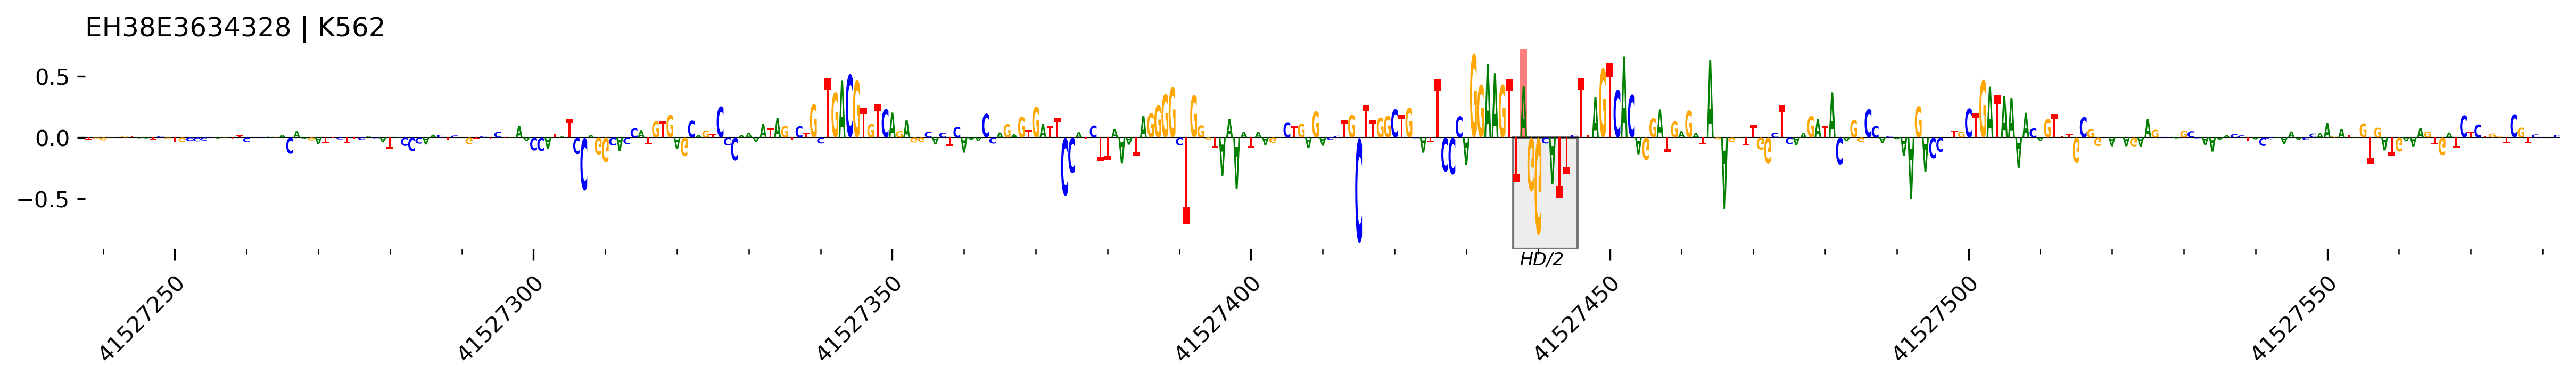

In [21]:
# COSV66186902
plot_specific_enhancers_v2('EH38E3634328',
                           41527237,
                           'chr5',
                           k_dELS_seqlets,
                           'COSV66186902',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

In [ ]:
### Endometrioid Carcinoma ###
# Recurrent variants are enriched for:
# CUX/1, n=13
# SMARCA5, n=4
# IRF/1, n=5
# NR/1, n=4

In [25]:
# try plotting the CUX/1 first
cosmicPreds[cosmicPreds['id'].isin(caricomaPickle['endometrioid_carcinoma']['CUX/1']) & (cosmicPreds['emvar_any'] == 1)]
# no emVars

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_pro_seqlet,250_pro_seqlet,k562_dELS_seqlet_tf_fam,hepg2_dELS_seqlet_tf_fam,sknsh_dELS_seqlet_tf_fam,k562_dELS_seqlet_enh_ID,hepg2_dELS_seqlet_enh_ID,sknsh_dELS_seqlet_enh_ID,primary_histology,all_histology


In [30]:
# try plotting the SMARCA5 vars
cosmicPreds[cosmicPreds['id'].isin(caricomaPickle['endometrioid_carcinoma']['SMARCA5']) & (cosmicPreds['emvar_any'] == 1)]
# no emVars

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_pro_seqlet,250_pro_seqlet,k562_dELS_seqlet_tf_fam,hepg2_dELS_seqlet_tf_fam,sknsh_dELS_seqlet_tf_fam,k562_dELS_seqlet_enh_ID,hepg2_dELS_seqlet_enh_ID,sknsh_dELS_seqlet_enh_ID,primary_histology,all_histology


In [31]:
# try plotting the IRF/1 vars
cosmicPreds[cosmicPreds['id'].isin(caricomaPickle['endometrioid_carcinoma']['IRF/1']) & (cosmicPreds['emvar_any'] == 1)]

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_pro_seqlet,250_pro_seqlet,k562_dELS_seqlet_tf_fam,hepg2_dELS_seqlet_tf_fam,sknsh_dELS_seqlet_tf_fam,k562_dELS_seqlet_enh_ID,hepg2_dELS_seqlet_enh_ID,sknsh_dELS_seqlet_enh_ID,primary_histology,all_histology
789427,chr7,151565752,COSV55228535,C,T,1.128404,0.979406,-0.148998,0.472028,1.107062,...,0,0,IRF/1,0,0,EH38E3809001,0,0,carcinoma,carcinoma


Saved plot: plot_outputs/EH38E3809001_K562_COSV55228535_logo.pdf


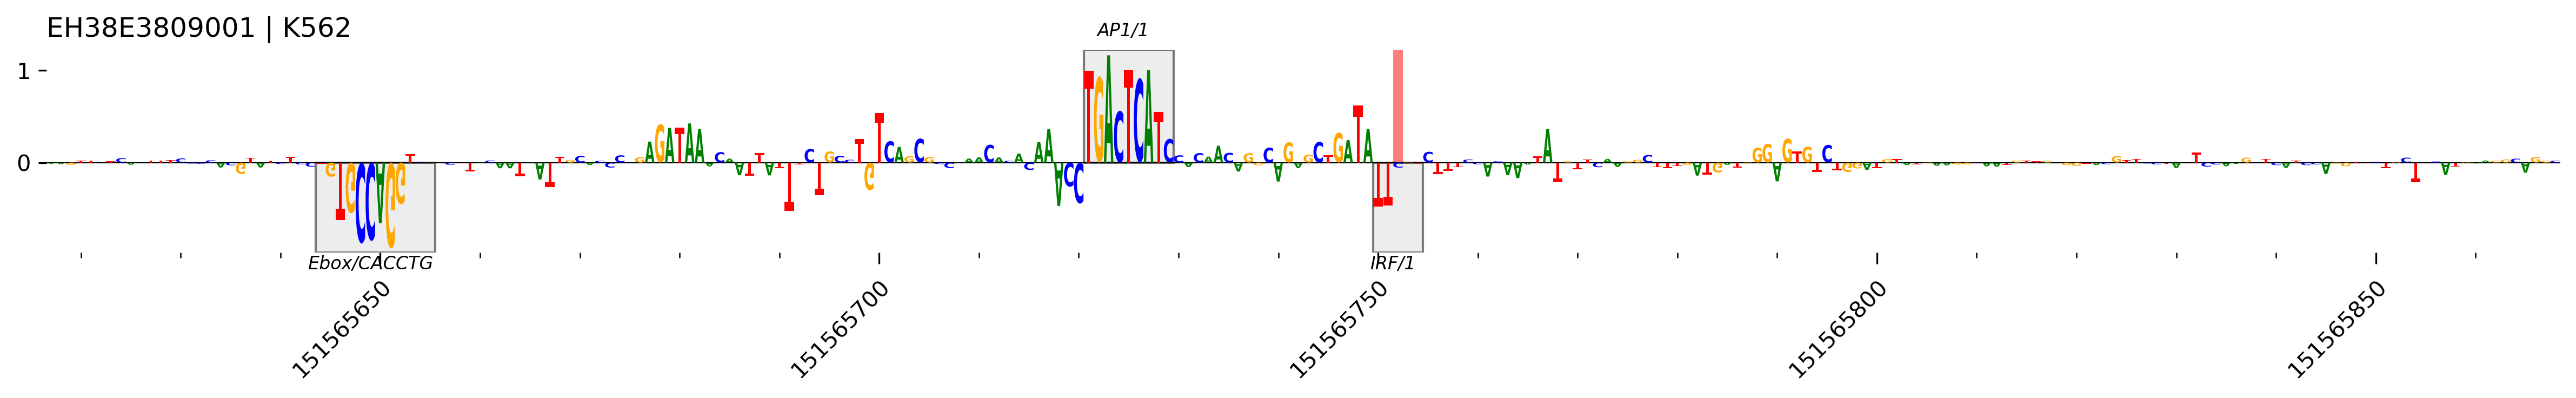

In [32]:
# COSV55228535
plot_specific_enhancers_v2('EH38E3809001',
                           151565616,
                           'chr7',
                           k_dELS_seqlets,
                           'COSV55228535',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

In [33]:
# try plotting the NR/1 vars
cosmicPreds[cosmicPreds['id'].isin(caricomaPickle['endometrioid_carcinoma']['NR/1']) & (cosmicPreds['emvar_any'] == 1)]

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_pro_seqlet,250_pro_seqlet,k562_dELS_seqlet_tf_fam,hepg2_dELS_seqlet_tf_fam,sknsh_dELS_seqlet_tf_fam,k562_dELS_seqlet_enh_ID,hepg2_dELS_seqlet_enh_ID,sknsh_dELS_seqlet_enh_ID,primary_histology,all_histology
2334849,chr1,31744648,COSV57079113,C,A,2.173125,2.781821,0.608696,2.897482,3.315964,...,0,0,NR/1,NR/1,NR/1,EH38E1334455,EH38E1334455,EH38E1334455,carcinoma,carcinoma


Saved plot: plot_outputs/EH38E1334455_K562_COSV57079113_logo.pdf


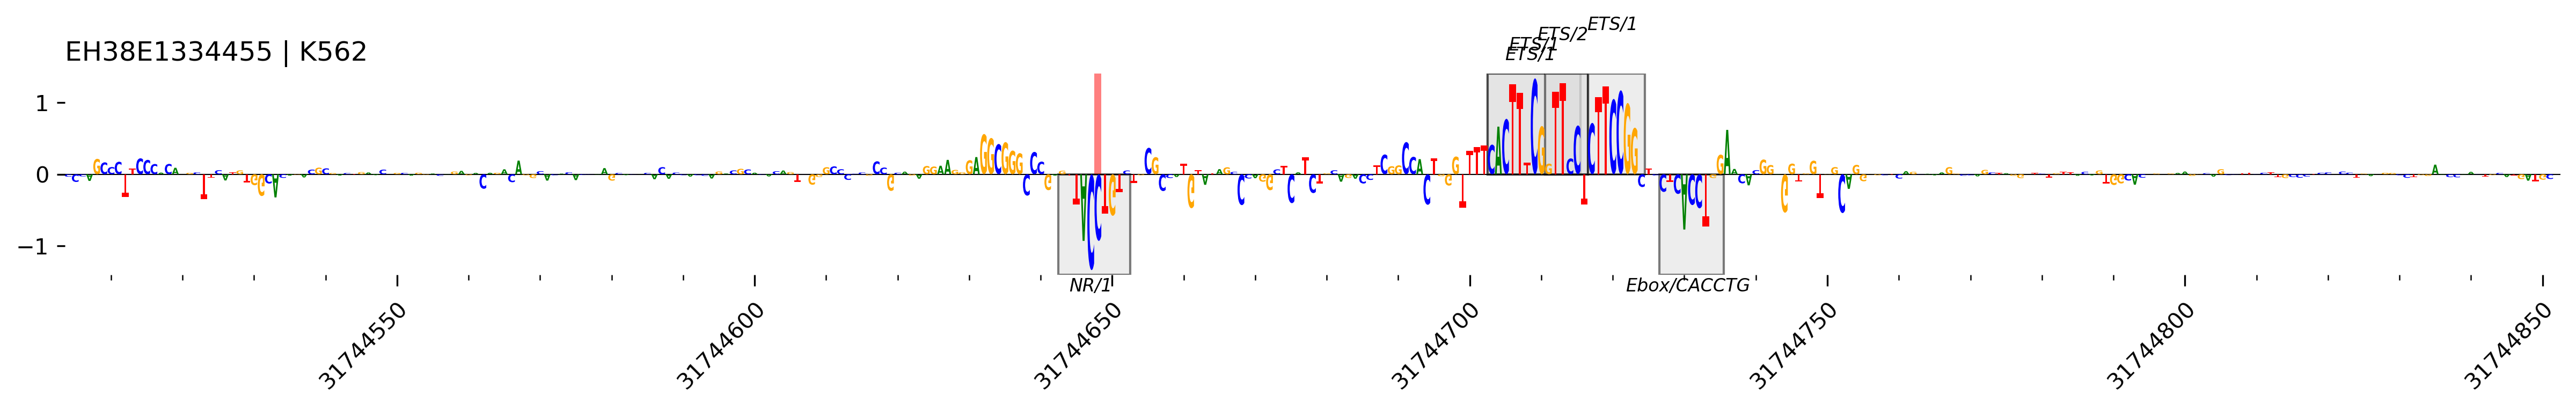

In [34]:
# COSV57079113
plot_specific_enhancers_v2('EH38E1334455',
                           31744503,
                           'chr1',
                           k_dELS_seqlets,
                           'COSV57079113',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

In [ ]:
### Squamous Cell Carcinoma ###
# Recurrent variants are enriched for:
# Ebox/CAGCTG, n=4

In [51]:
# Ebox/CAGCTG 
cosmicPreds[cosmicPreds['id'].isin(caricomaPickle['squamous_cell_carcinoma']['Ebox/CAGCTG']) & (cosmicPreds['emvar_any'] == 1)]

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_pro_seqlet,250_pro_seqlet,k562_dELS_seqlet_tf_fam,hepg2_dELS_seqlet_tf_fam,sknsh_dELS_seqlet_tf_fam,k562_dELS_seqlet_enh_ID,hepg2_dELS_seqlet_enh_ID,sknsh_dELS_seqlet_enh_ID,primary_histology,all_histology


In [ ]:
### Hepatocellular Carcinoma ###
# Recurrent variants are enriched for:
# CREB/ATF/3, n=11
# SMAD, n=3

In [44]:
# CREB/ATF/3
cosmicPreds[cosmicPreds['id'].isin(caricomaPickle['hepatocellular_carcinoma']['CREB/ATF/3']) & (cosmicPreds['emvar_any'] == 1)]

,chrom,pos,id,ref,alt,k562_ref_pred,k562_alt_pred,k562_skew_pred,hepg2_ref_pred,hepg2_alt_pred,...,sknsh_pro_seqlet,250_pro_seqlet,k562_dELS_seqlet_tf_fam,hepg2_dELS_seqlet_tf_fam,sknsh_dELS_seqlet_tf_fam,k562_dELS_seqlet_enh_ID,hepg2_dELS_seqlet_enh_ID,sknsh_dELS_seqlet_enh_ID,primary_histology,all_histology


In [12]:
# SMAD
cosmicPreds[cosmicPreds['id'].isin(caricomaPickle['hepatocellular_carcinoma']['SMAD']) & (cosmicPreds['emvar_any'] == 1)].filter(['hepg2_skew_pred', 'sknsh_skew_pred', 'id'])

,hepg2_skew_pred,sknsh_skew_pred,id
607484,0.125708,0.797688,COSV53312542


Saved plot: plot_outputs/EH38E3299611_HepG2_COSV53312542_logo.pdf


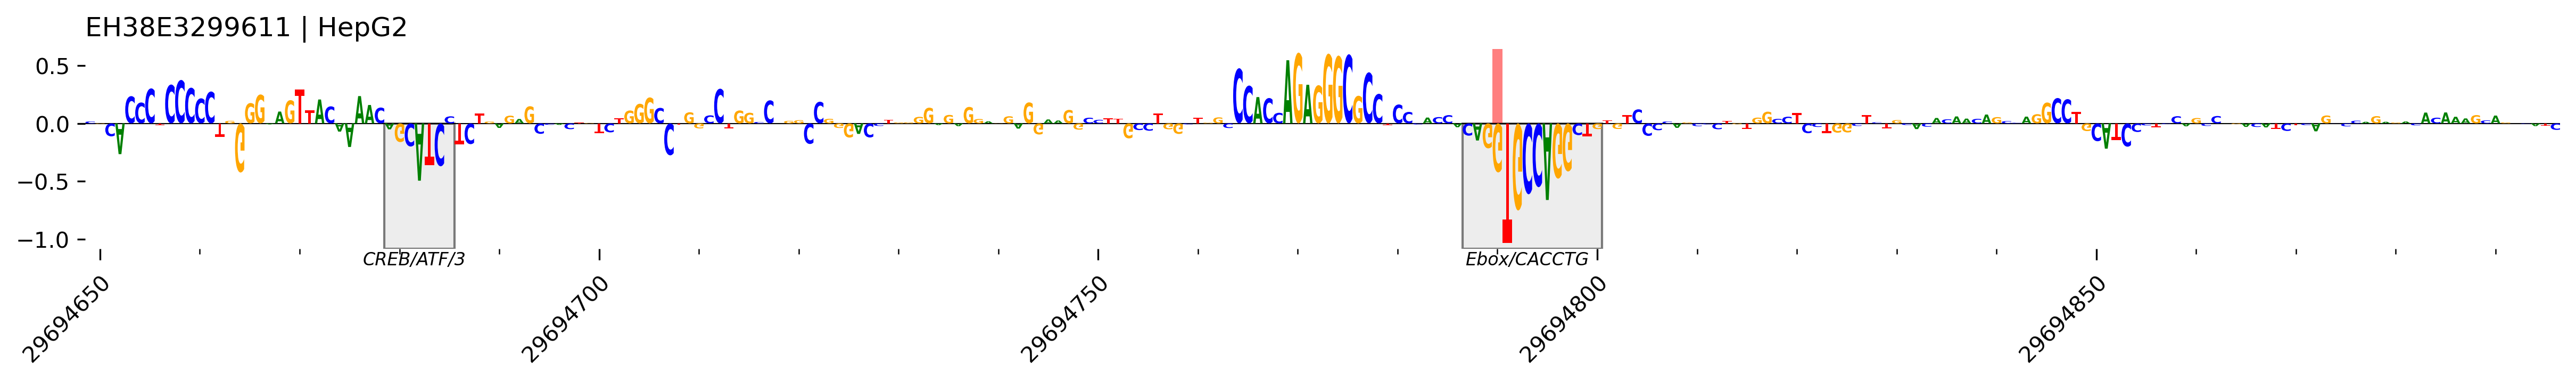

In [7]:
# COSV53312542
plot_specific_enhancers_v2('EH38E3299611',
                           29694648,
                           'chr19',
                           h_dELS_seqlets,
                           'COSV53312542',
                           cosmicPreds,
                           'HepG2',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3299611_SKNSH_COSV53312542_logo.pdf


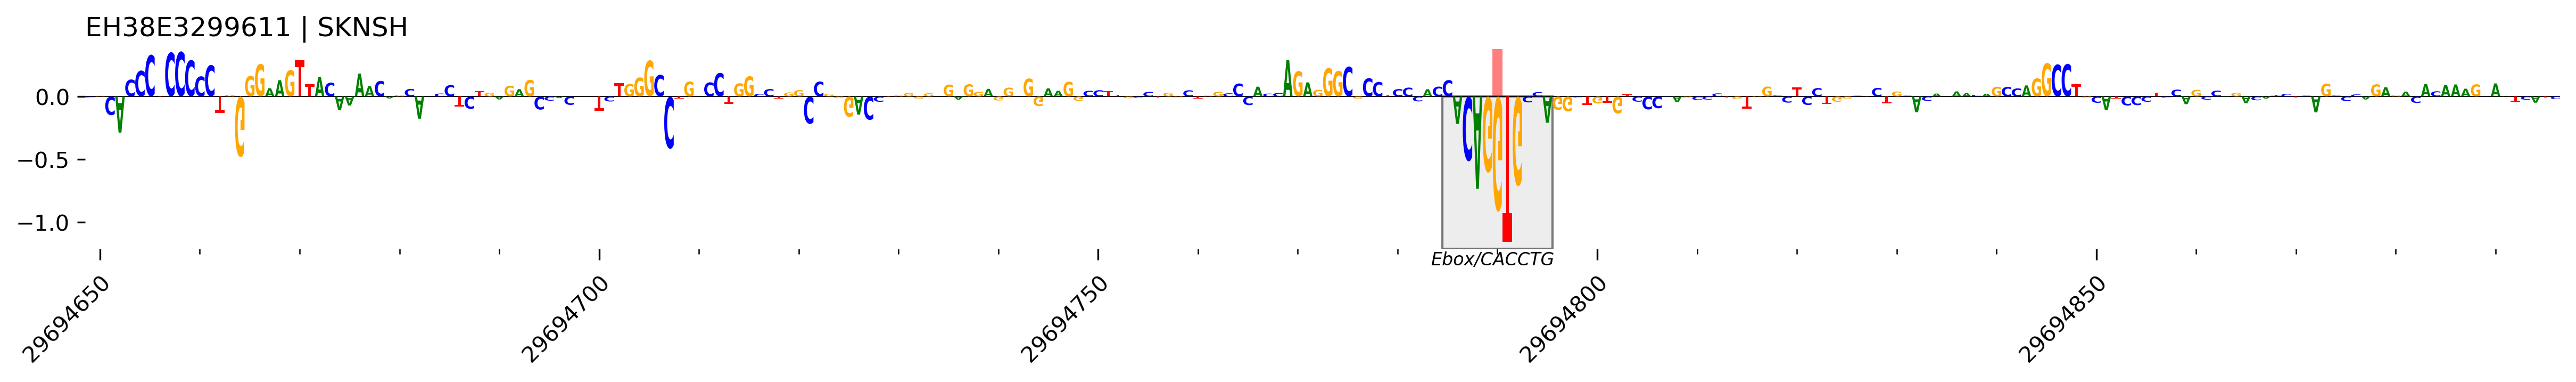

In [6]:
# COSV53312542
plot_specific_enhancers_v2('EH38E3299611',
                           29694648,
                           'chr19',
                           s_dELS_seqlets,
                           'COSV53312542',
                           cosmicPreds,
                           'SKNSH',
                           output_dir='plot_outputs')

In [52]:
### Malignant Melanoma ###

Saved plot: plot_outputs/EH38E3812033_K562_COSV104689316_logo.pdf


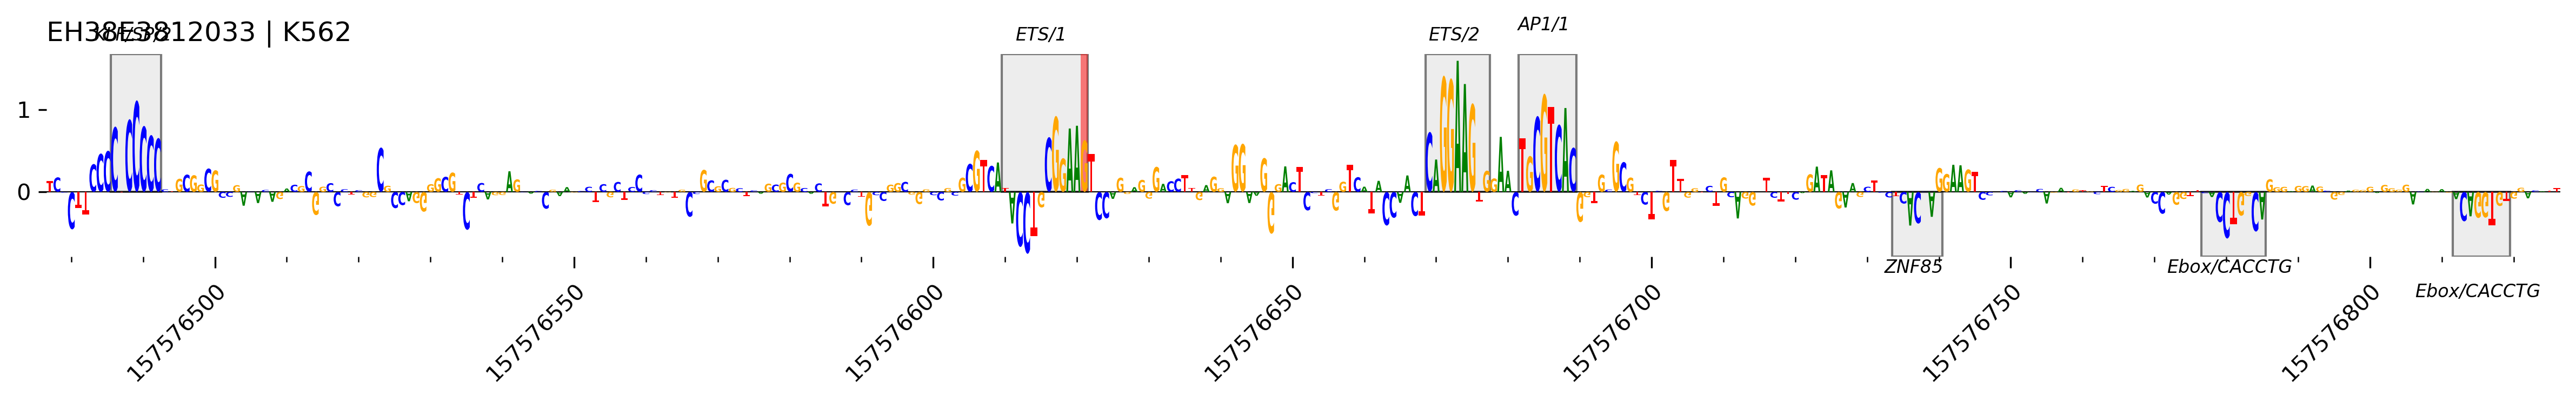

In [8]:
# COSV104689316
plot_specific_enhancers_v2('EH38E3812033',
                           157576476,
                           'chr7',
                           k_dELS_seqlets,
                           'COSV104689316',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3014289_K562_COSV104553639_logo.pdf


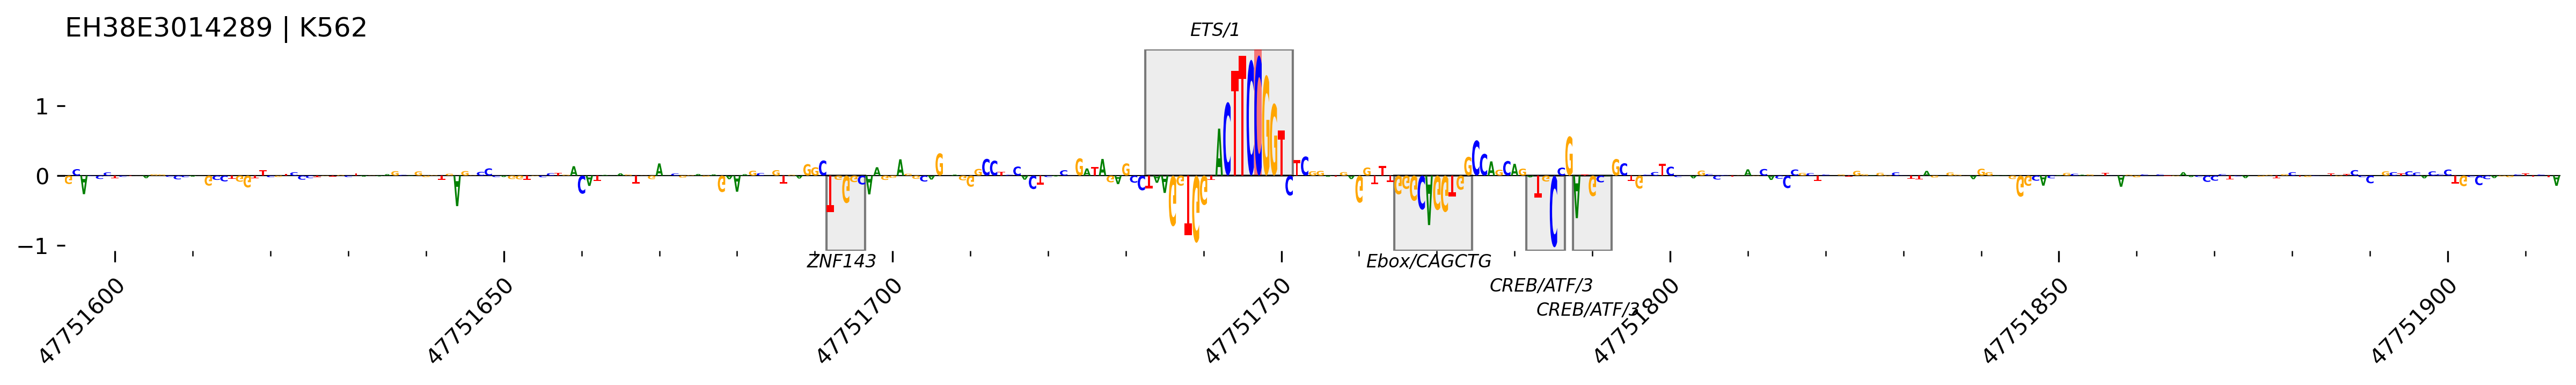

In [9]:
# COSV104553639
plot_specific_enhancers_v2('EH38E3014289',
                           47751593,
                           'chr12',
                           k_dELS_seqlets,
                           'COSV104553639',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E4037596_K562_COSV104560128_logo.pdf


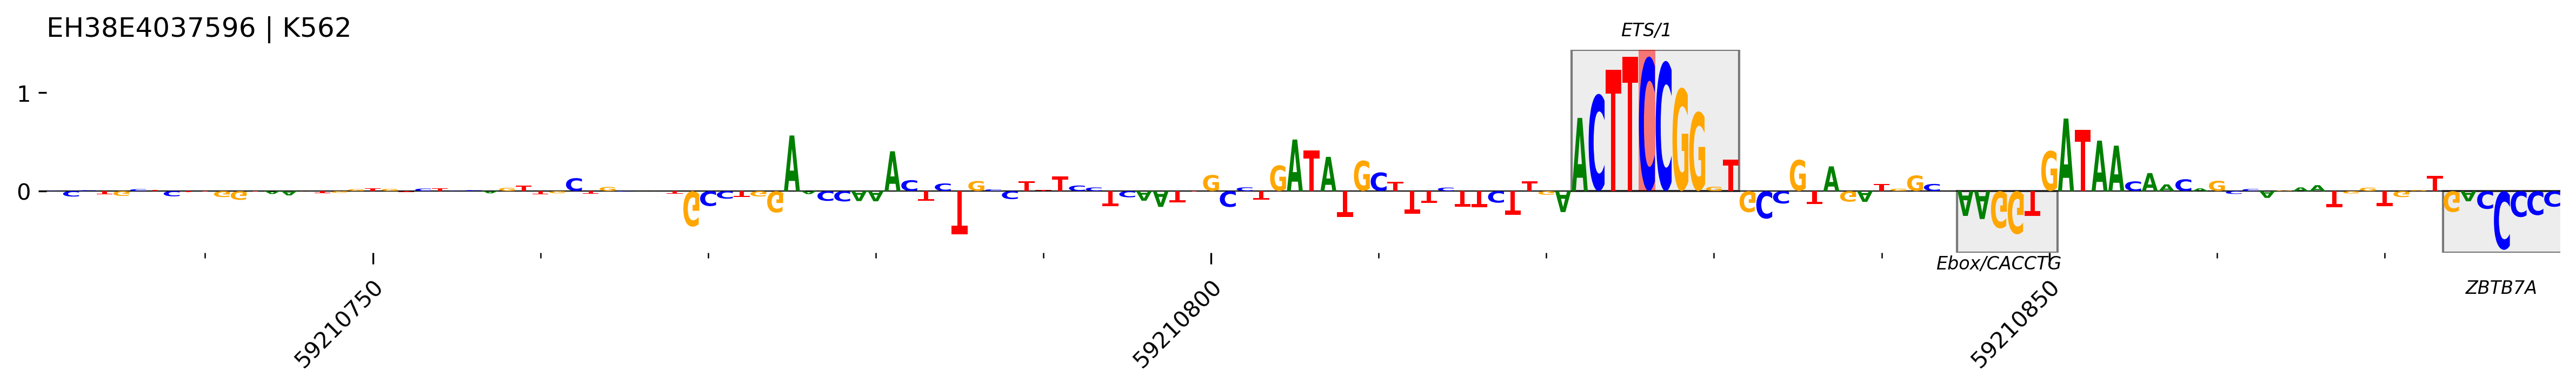

In [10]:
# COSV104560128
plot_specific_enhancers_v2('EH38E4037596',
                           59210730,
                           'chr11',
                           k_dELS_seqlets,
                           'COSV104560128',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E2962916_SKNSH_COSV99657319_logo.pdf


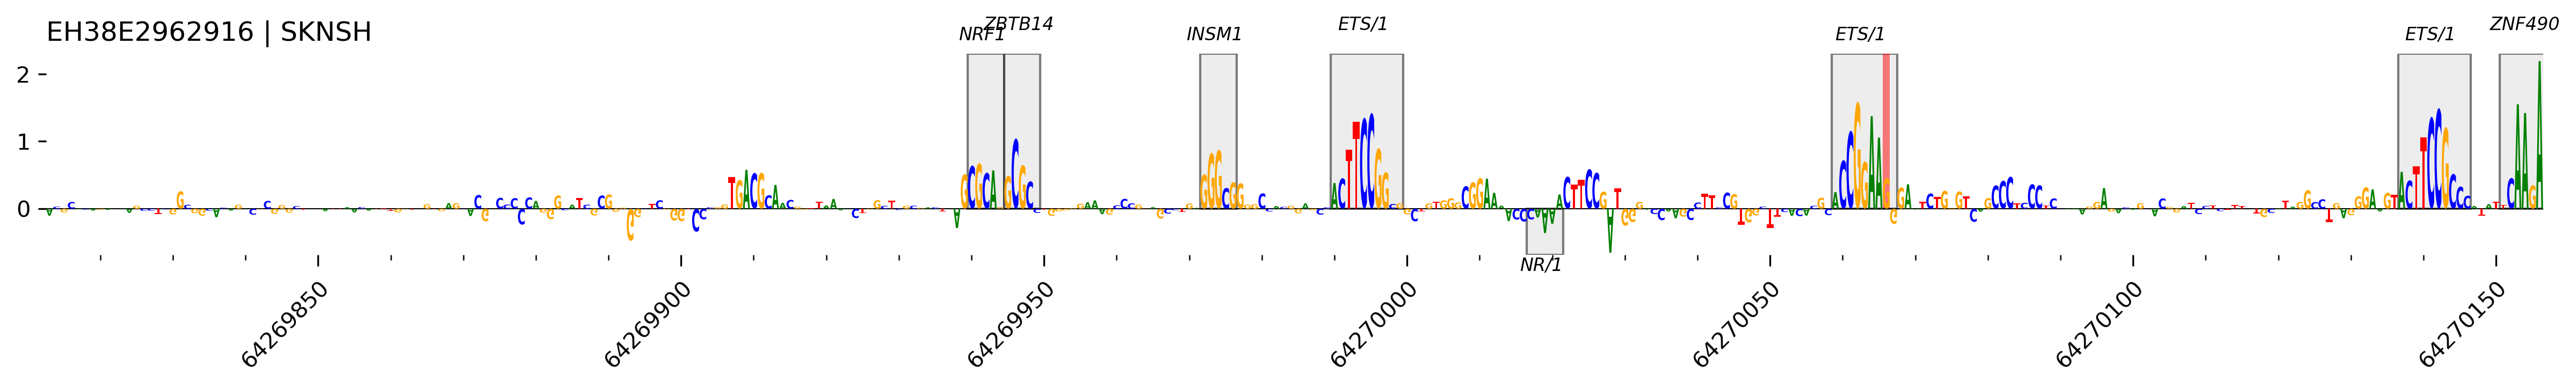

In [12]:
# COSV99657319
plot_specific_enhancers_v2('EH38E2962916',
                           64269812,
                           'chr11',
                           s_dELS_seqlets,
                           'COSV99657319',
                           cosmicPreds,
                           'SKNSH',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E2962916_SKNSH_COSV54189042_logo.pdf


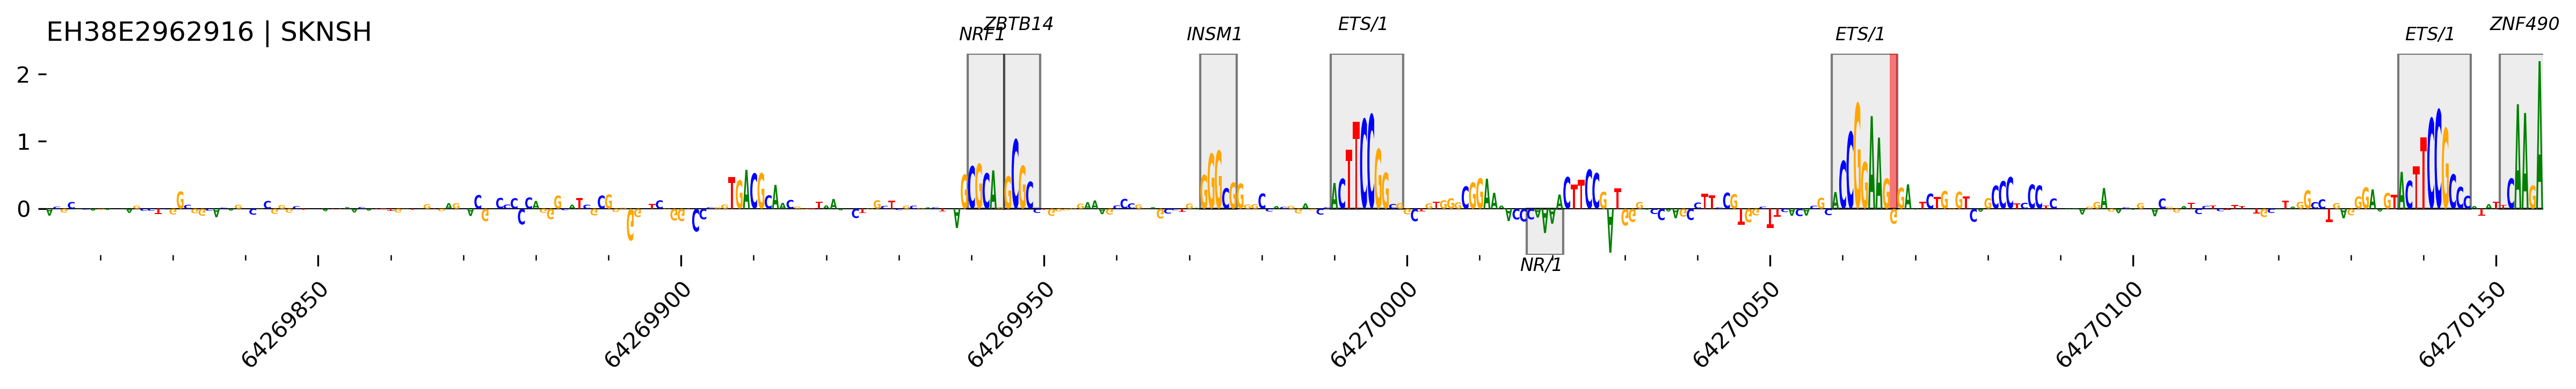

In [13]:
# COSV54189042
plot_specific_enhancers_v2('EH38E2962916',
                           64269812,
                           'chr11',
                           s_dELS_seqlets,
                           'COSV54189042',
                           cosmicPreds,
                           'SKNSH',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3882280_K562_COSV104671442_logo.pdf


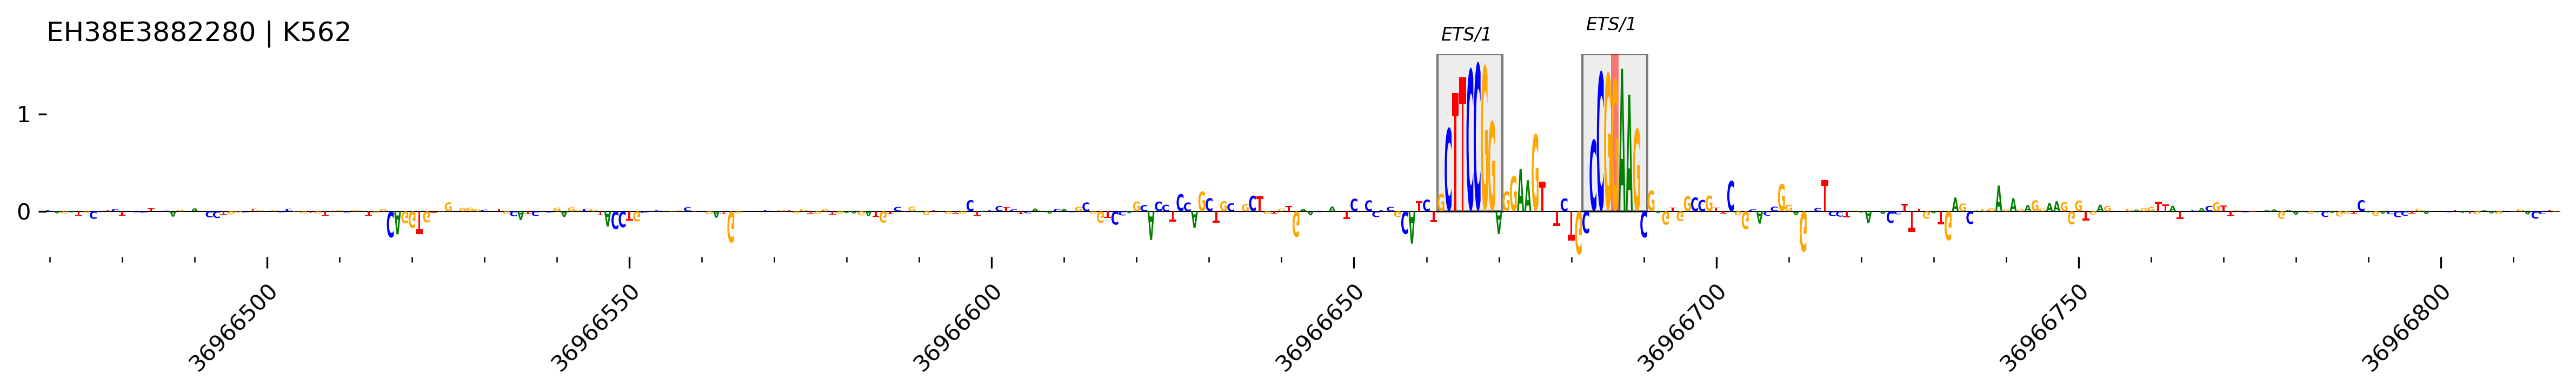

In [16]:
# COSV104671442
plot_specific_enhancers_v2('EH38E3882280',
                           36966469,
                           'chr9',
                           k_dELS_seqlets,
                           'COSV104671442',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3185757_HepG2_COSV104659023_logo.pdf


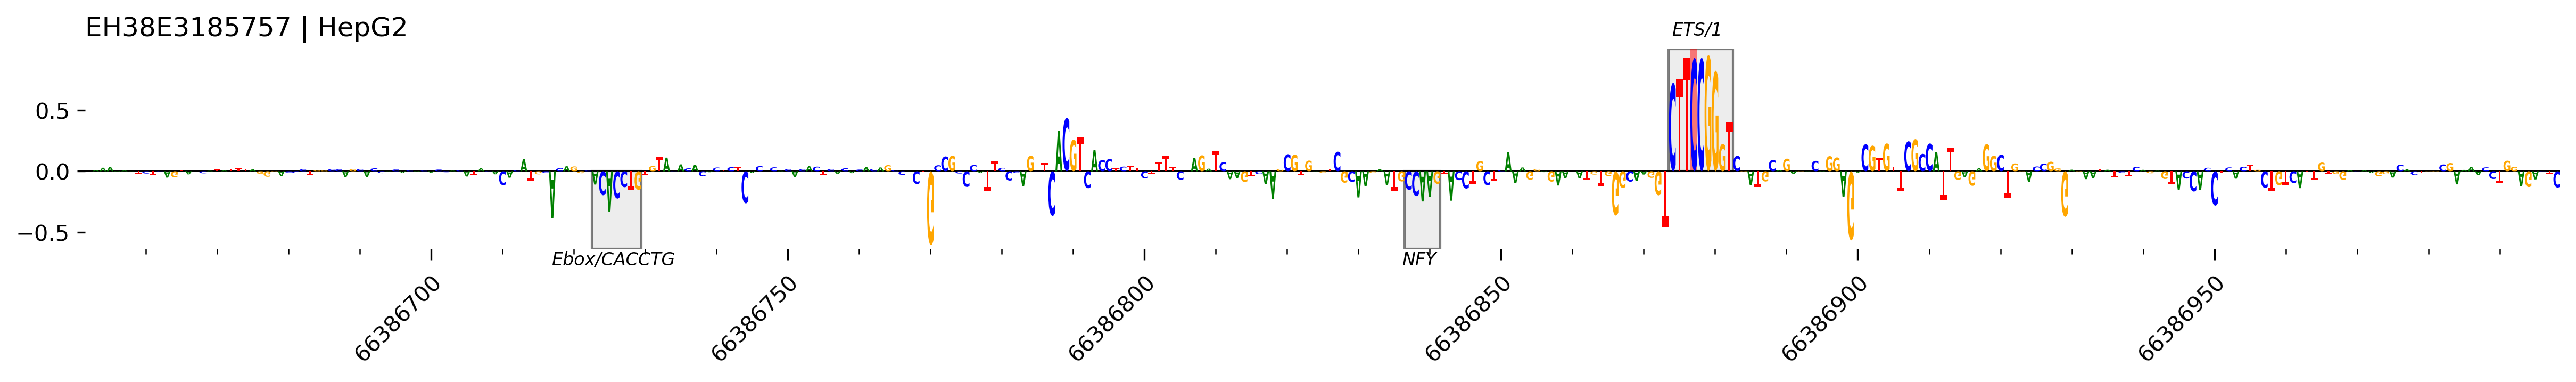

In [18]:
# COSV104659023
plot_specific_enhancers_v2('EH38E3185757',
                           66386651,
                           'chr16',
                           h_dELS_seqlets,
                           'COSV104659023',
                           cosmicPreds,
                           'HepG2',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E2937040_K562_COSV99428876_logo.pdf


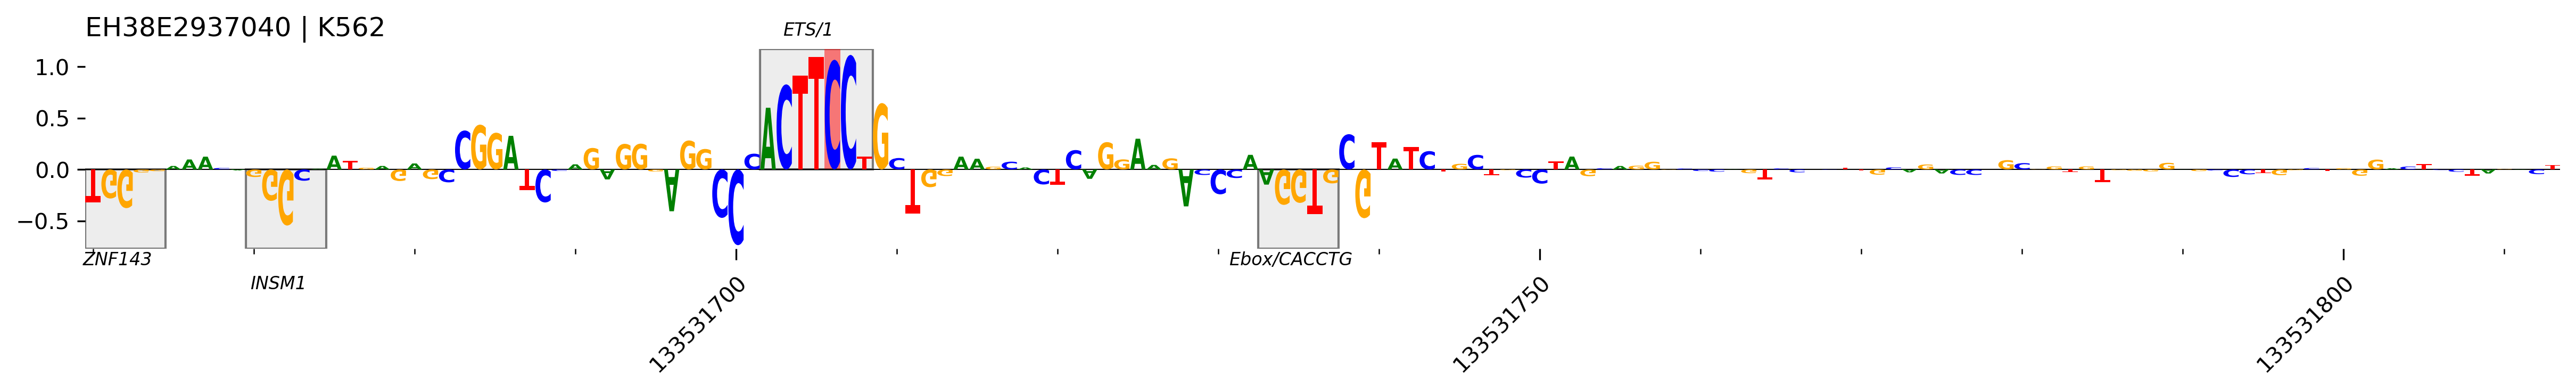

In [19]:
# COSV99428876
plot_specific_enhancers_v2('EH38E2937040',
                           133531659,
                           'chr10',
                           k_dELS_seqlets,
                           'COSV99428876',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3342218_K562_COSV104560809_logo.pdf


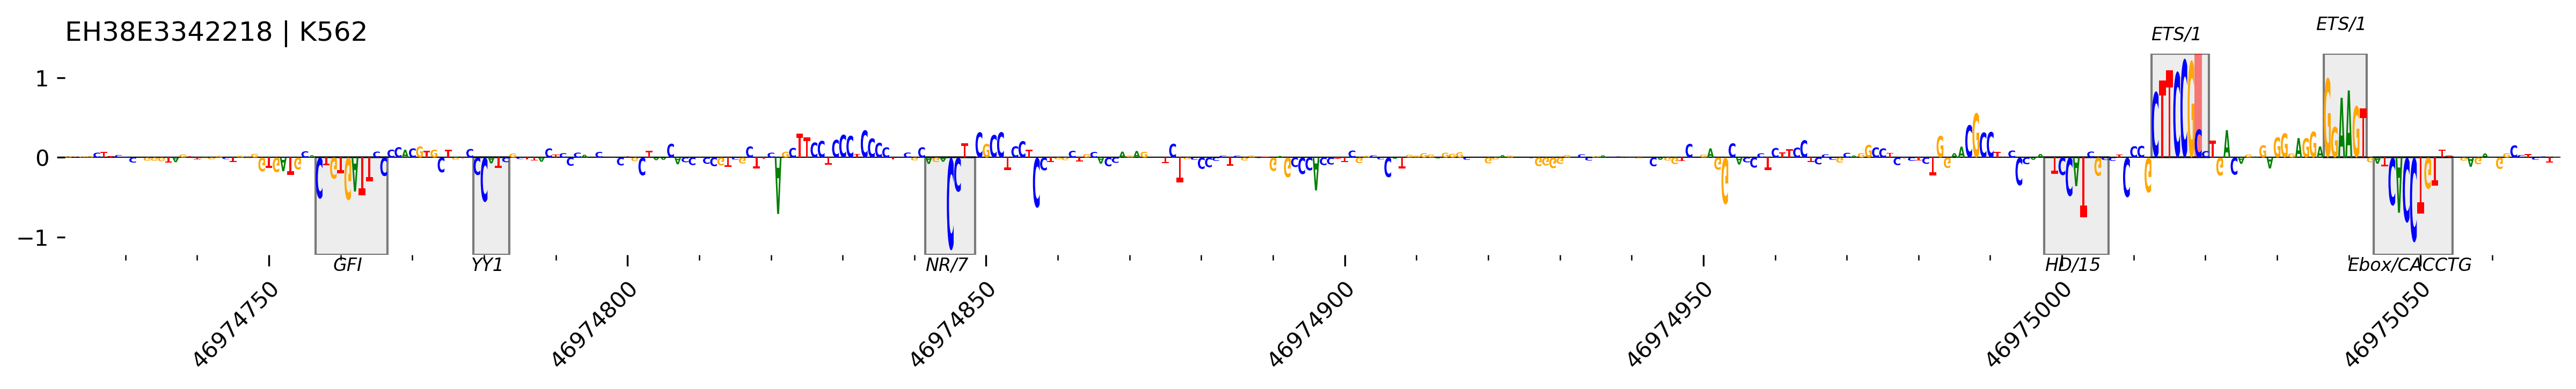

In [20]:
# COSV104560809
plot_specific_enhancers_v2('EH38E3342218',
                           46974721,
                           'chr2',
                           k_dELS_seqlets,
                           'COSV104560809',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3392252_SKNSH_COSV104531549_logo.pdf


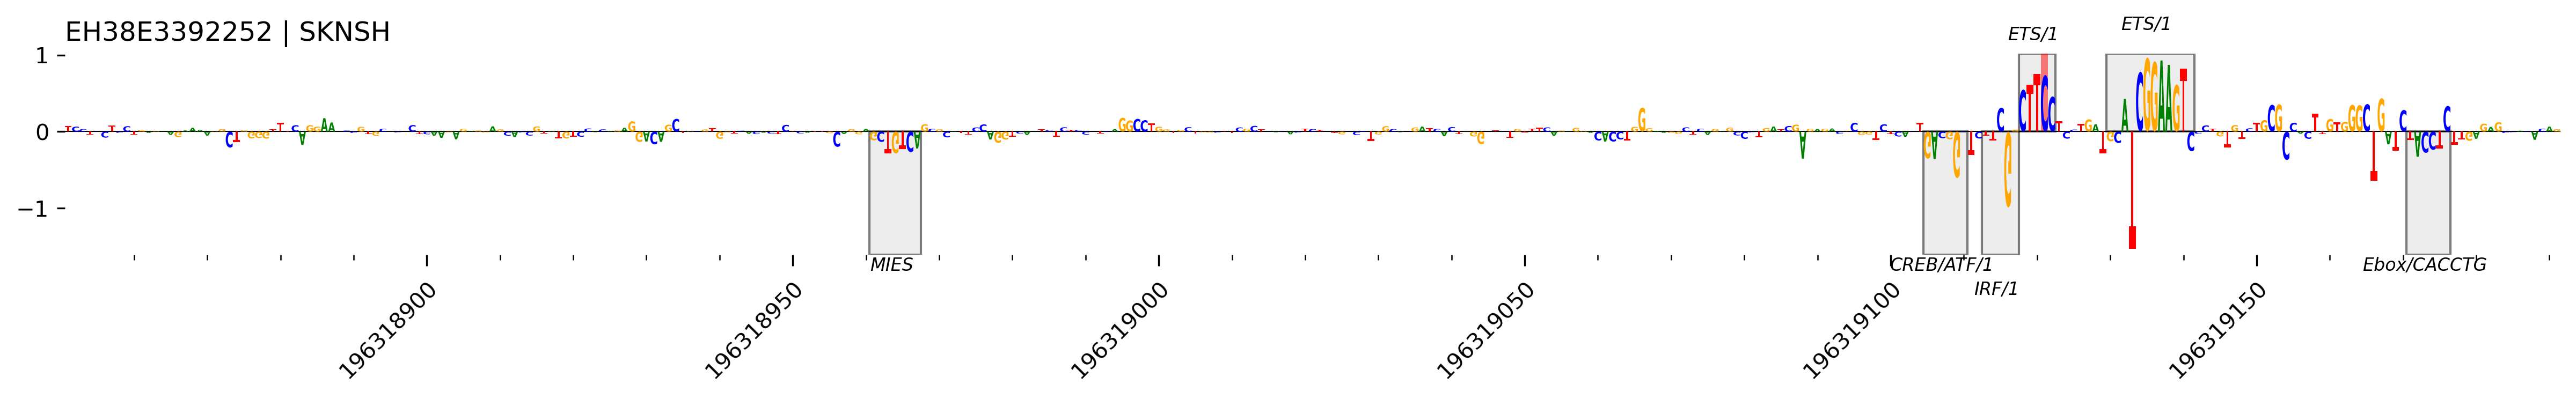

In [21]:
# COSV104531549
plot_specific_enhancers_v2('EH38E3392252',
                           196318850,
                           'chr2',
                           s_dELS_seqlets,
                           'COSV104531549',
                           cosmicPreds,
                           'SKNSH',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3822969_K562_COSV104670216_logo.pdf


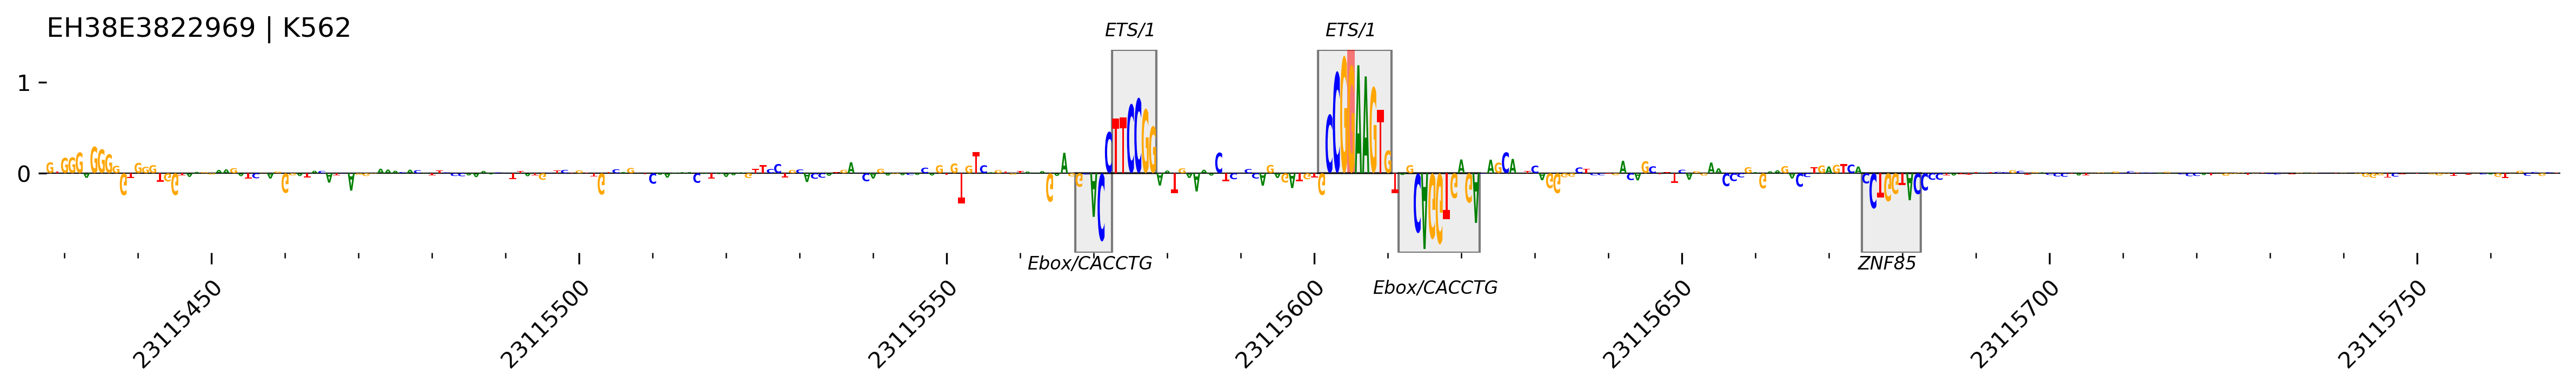

In [24]:
# COSV104670216
plot_specific_enhancers_v2('EH38E3822969',
                           23115427,
                           'chr8',
                           k_dELS_seqlets,
                           'COSV104670216',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E1661078_K562_COSV104702689_logo.pdf


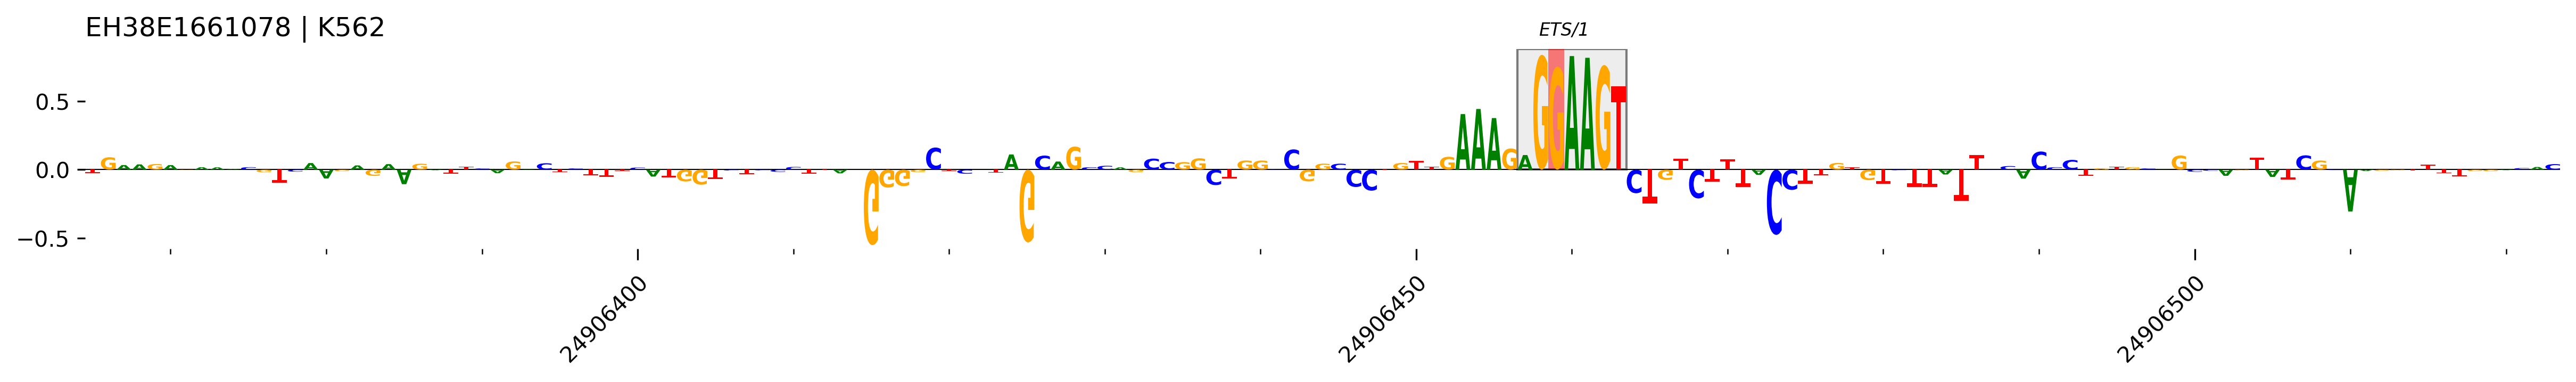

In [25]:
# COSV104702689
plot_specific_enhancers_v2('EH38E1661078',
                           24906364,
                           'chr13',
                           k_dELS_seqlets,
                           'COSV104702689',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3510594_HepG2_COSV104630745_logo.pdf


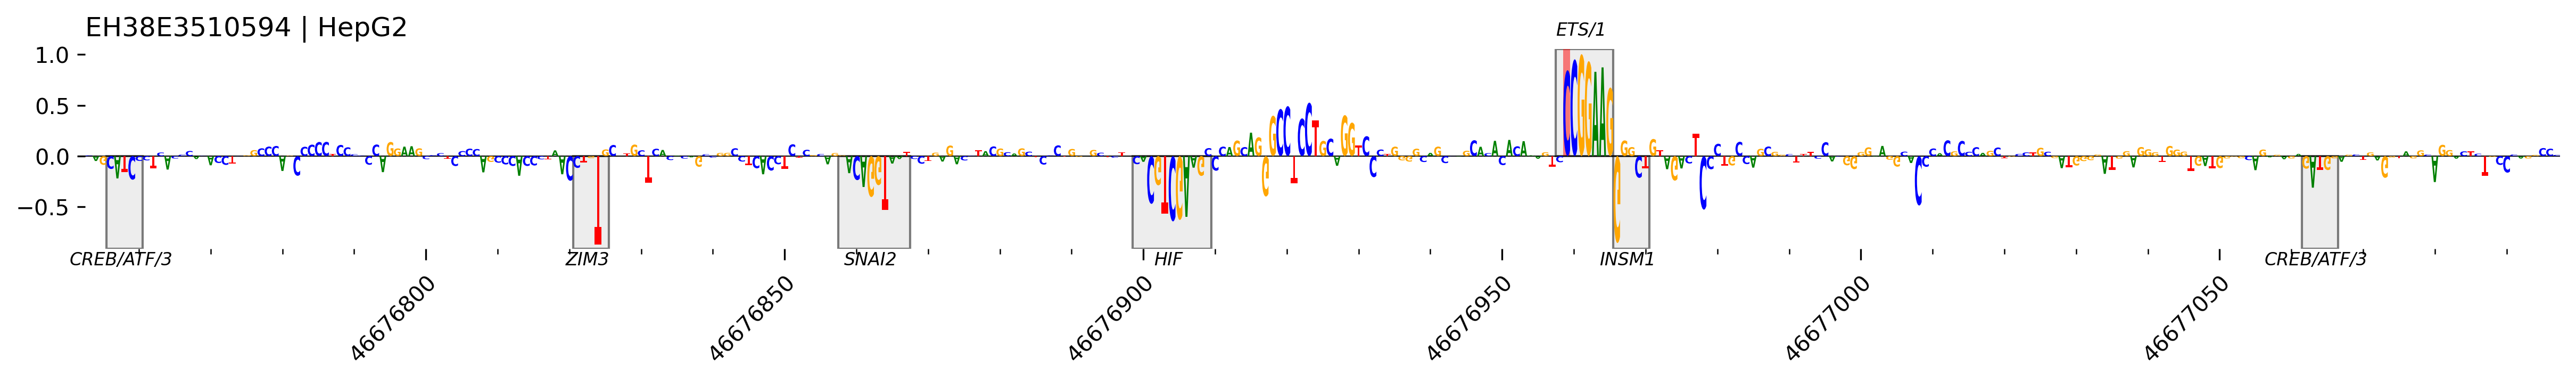

In [26]:
# COSV104630745
plot_specific_enhancers_v2('EH38E3510594',
                           46676752,
                           'chr3',
                           h_dELS_seqlets,
                           'COSV104630745',
                           cosmicPreds,
                           'HepG2',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3482162_HepG2_COSV104631518_logo.pdf


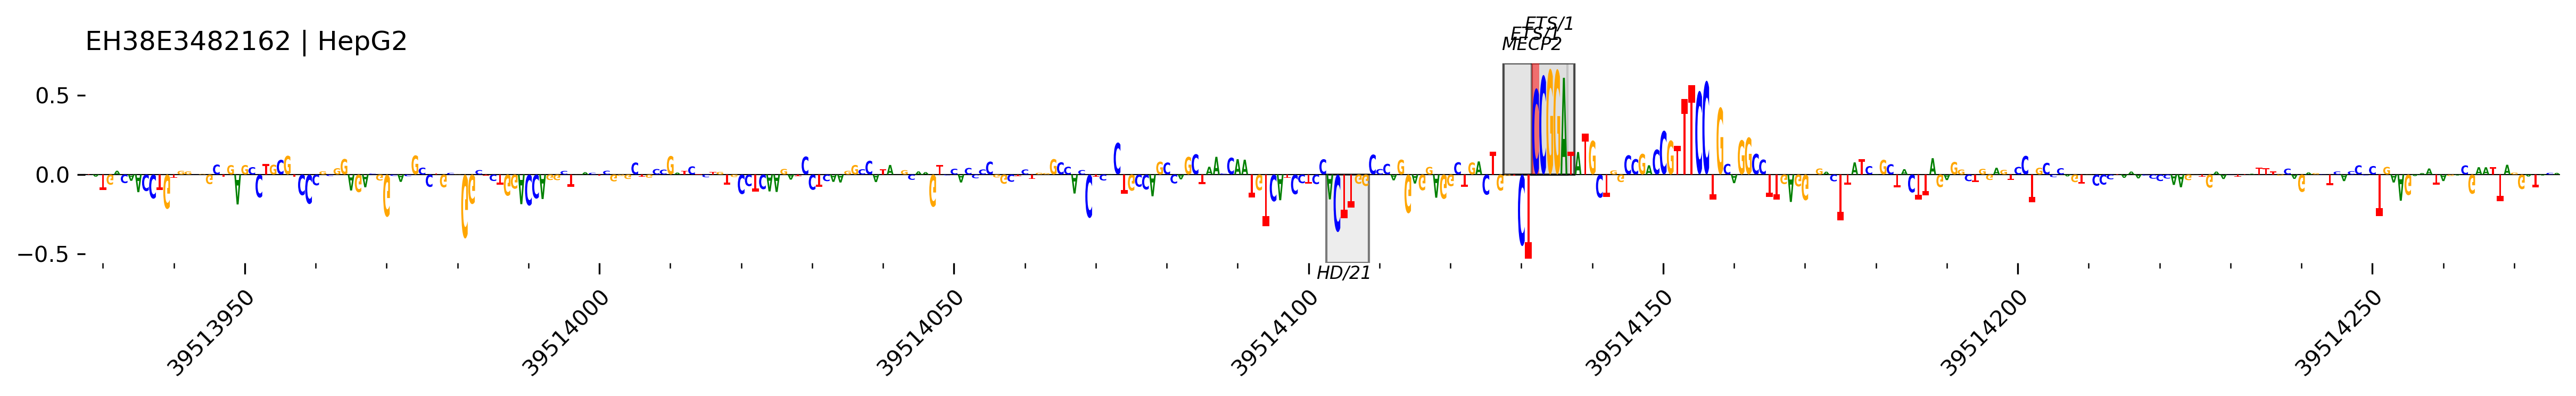

In [27]:
# COSV104631518
plot_specific_enhancers_v2('EH38E3482162',
                           39513927,
                           'chr22',
                           h_dELS_seqlets,
                           'COSV104631518',
                           cosmicPreds,
                           'HepG2',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E1339415_HepG2_COSV104614491_logo.pdf


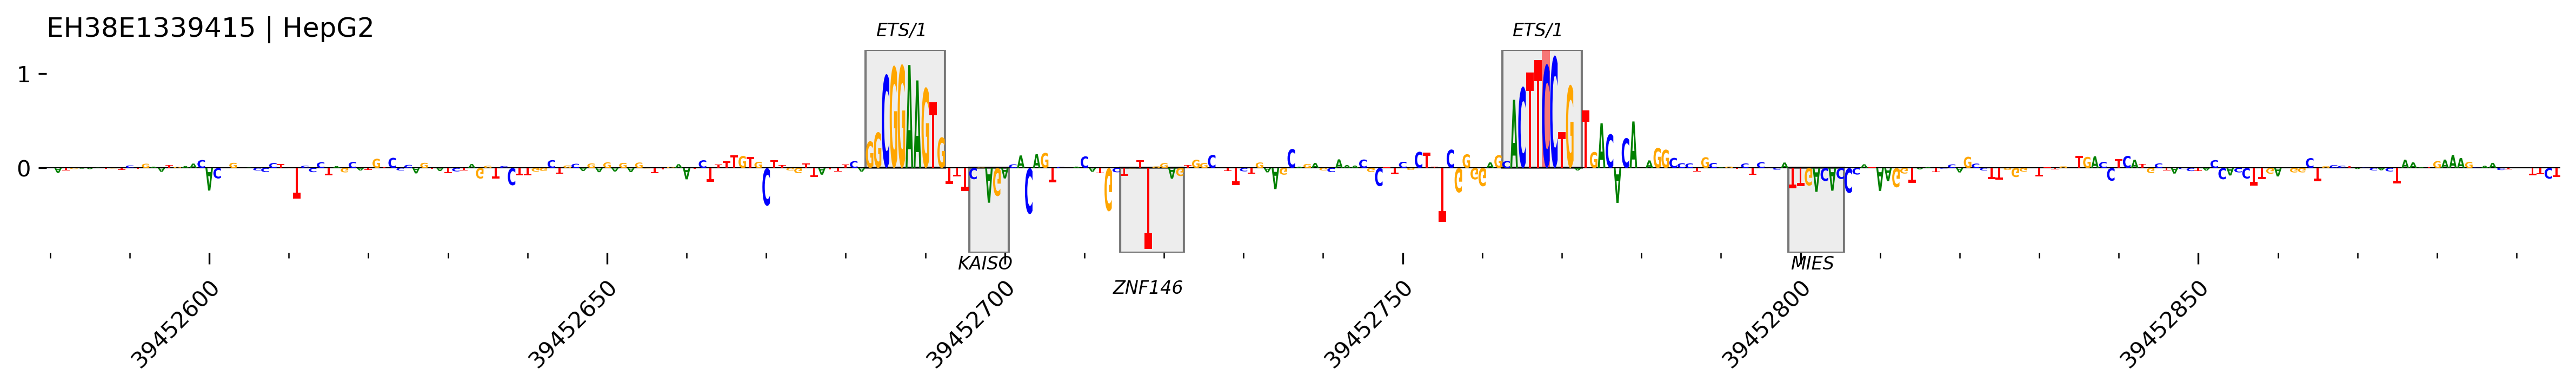

In [30]:
# COSV104614491
plot_specific_enhancers_v2('EH38E1339415',
                           39452579,
                           'chr1',
                           h_dELS_seqlets,
                           'COSV104614491',
                           cosmicPreds,
                           'HepG2',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3980860_HepG2_COSV63840353_logo.pdf


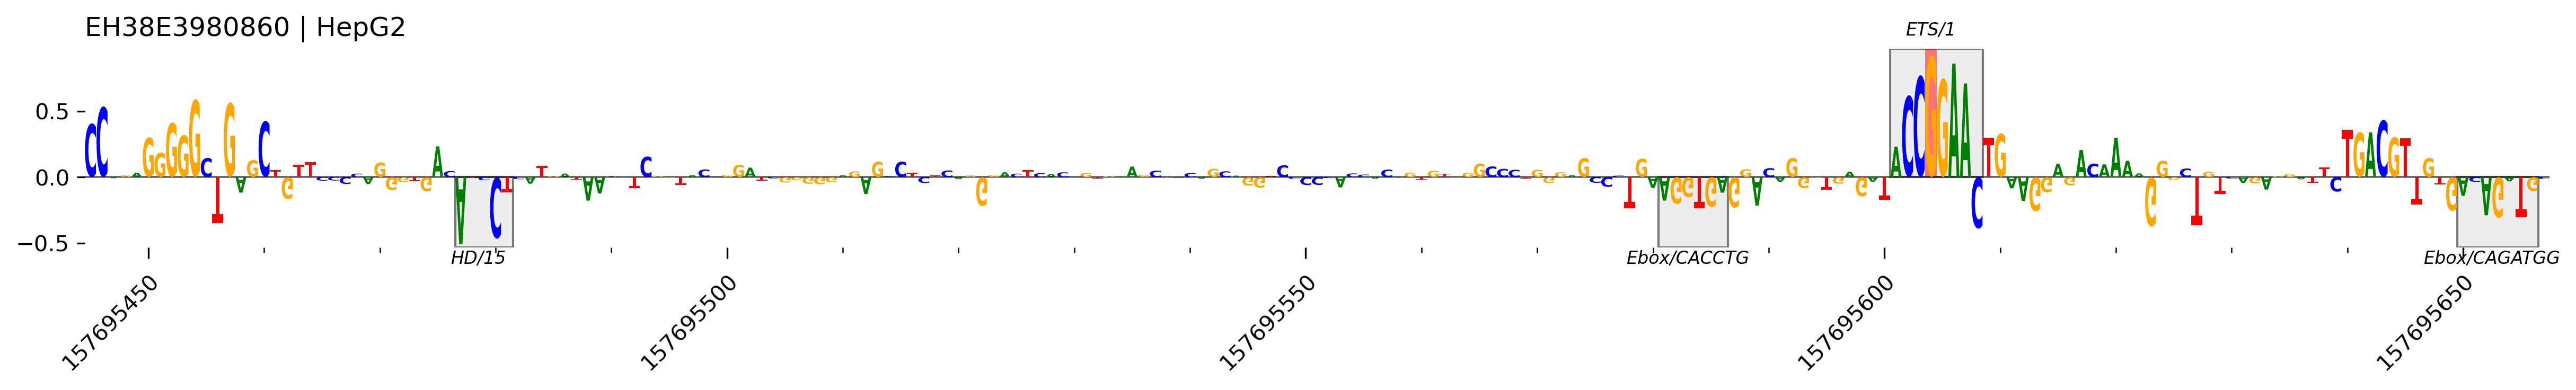

In [31]:
# COSV63840353
plot_specific_enhancers_v2('EH38E3980860',
                           157695444,
                           'chr1',
                           h_dELS_seqlets,
                           'COSV63840353',
                           cosmicPreds,
                           'HepG2',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E3830660_SKNSH_COSV104550898_logo.pdf


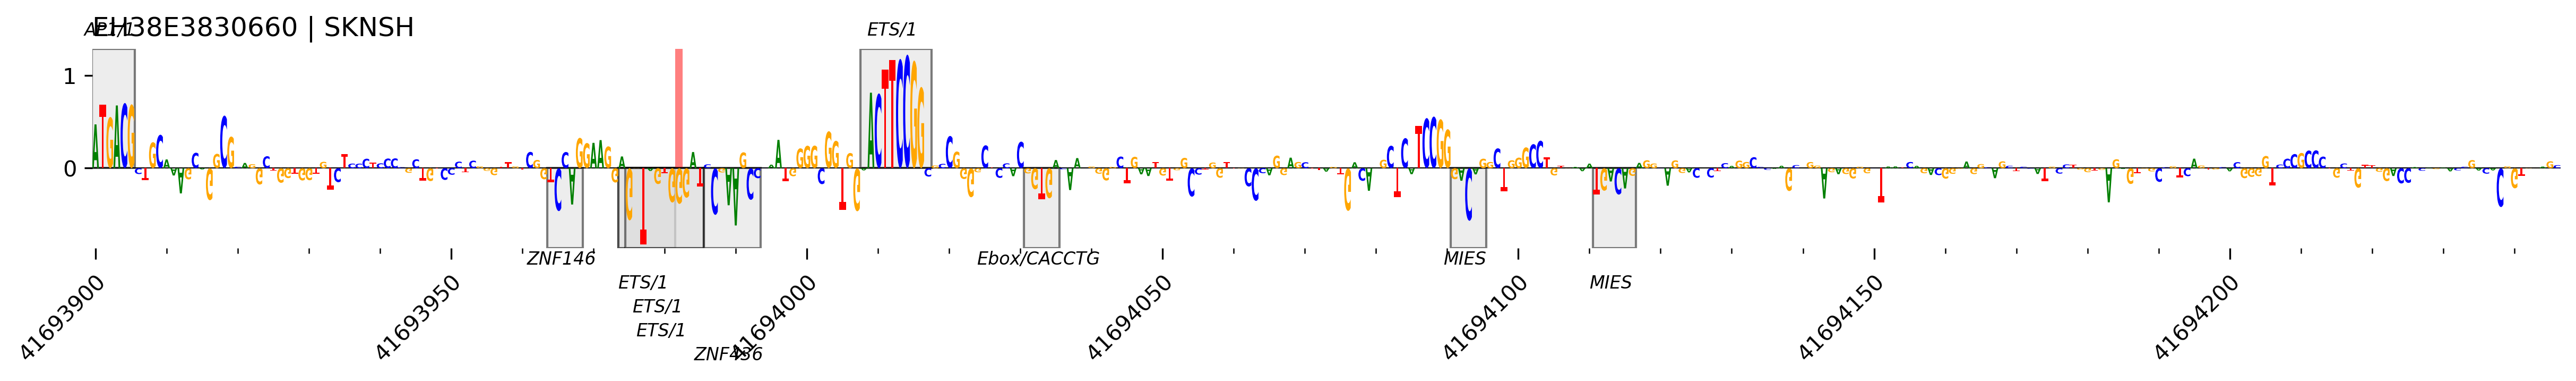

In [14]:
# COSV104550898
plot_specific_enhancers_v2('EH38E3822969',
                           23115427,
                           'chr8',
                           s_dELS_seqlets,
                           'COSV104550898',
                           cosmicPreds,
                           'SKNSH',
                           output_dir='plot_outputs')

In [7]:
### Melanoma: KLF/SP/1 ###

Saved plot: plot_outputs/EH38E3285143_K562_COSV104543977_logo.pdf


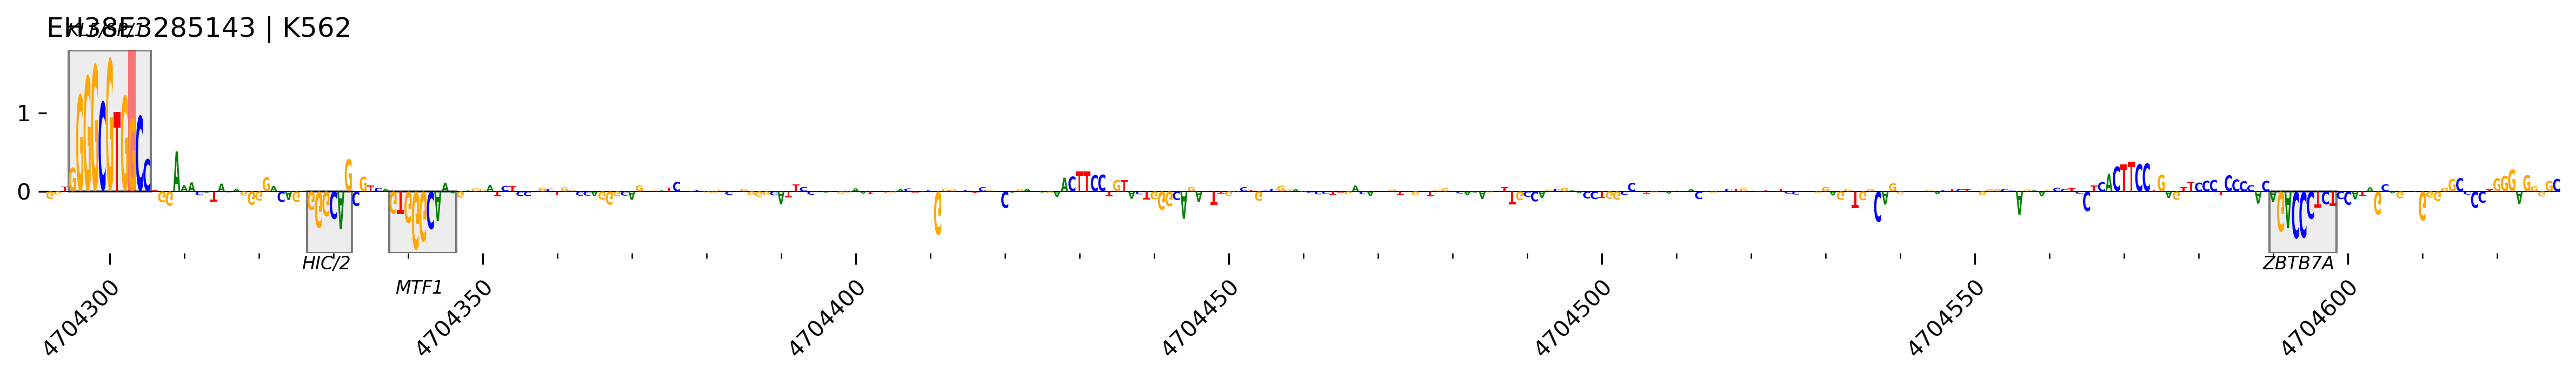

In [8]:
# COSV104543977
plot_specific_enhancers_v2('EH38E3285143',
                           4704291,
                           'chr19',
                           k_dELS_seqlets,
                           'COSV104543977',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')

Saved plot: plot_outputs/EH38E4127053_K562_COSV104635129_logo.pdf


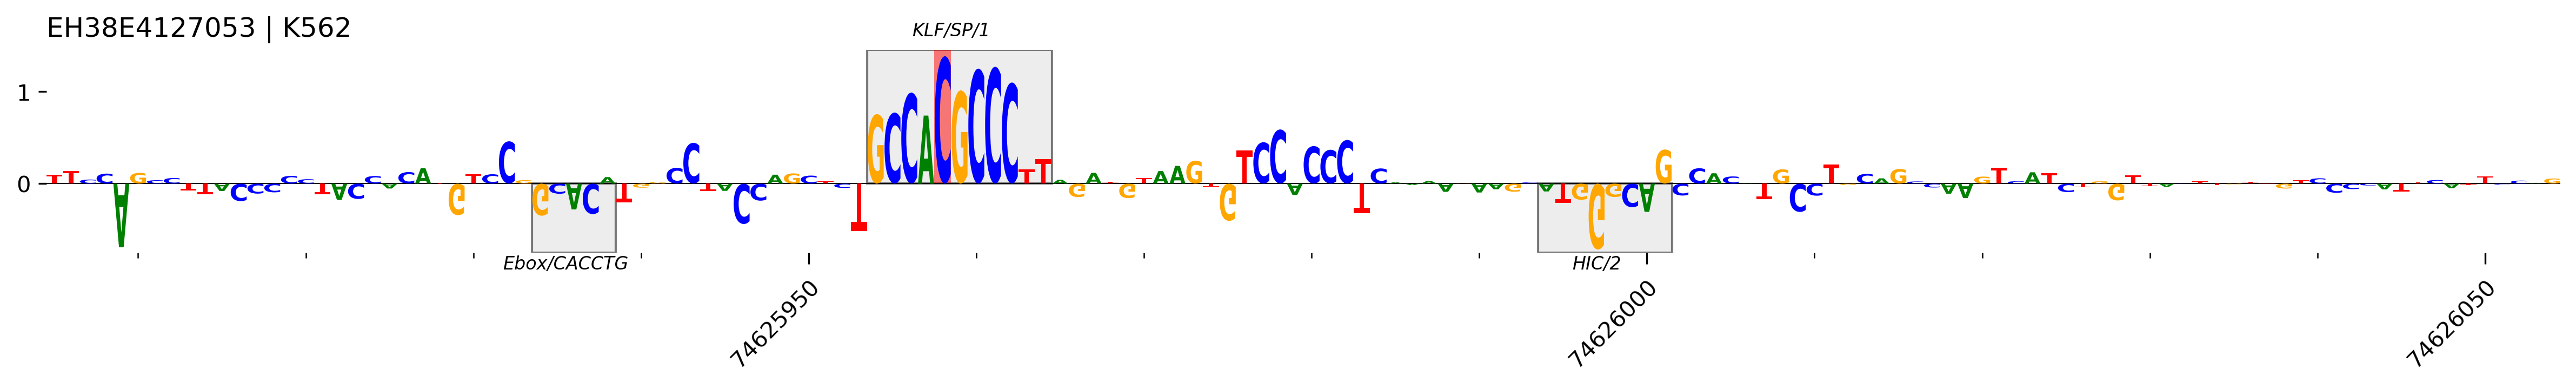

In [9]:
# COSV104635129
plot_specific_enhancers_v2('EH38E4127053',
                           74625904,
                           'chr15',
                           k_dELS_seqlets,
                           'COSV104635129',
                           cosmicPreds,
                           'K562',
                           output_dir='plot_outputs')